In [23]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

import pandas as pd
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger

In [24]:
Load_Path = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/Final/imgsize128/norm/dwt"

In [25]:

train_data = np.load(os.path.join(Load_Path, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(Load_Path, "tow_ids_test_dwt.npz"))
validation_data = np.load(os.path.join(Load_Path, "tow_ids_validation_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_validation = validation_data["X"]
y_validation = validation_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

print(X_train.shape, y_train.shape)
print(X_validation.shape, y_validation.shape)
print(X_test.shape, y_test.shape)


(26329, 64, 64, 3) (26329,)
(11284, 64, 64, 3) (11284,)
(24734, 64, 64, 3) (24734,)


In [26]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))
print("Validation label distribution :", np.unique(y_validation, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1]), array([11283, 15046]))
Test label distribution : (array([0, 1]), array([13167, 11567]))
Validation label distribution : (array([0, 1]), array([4835, 6449]))
Min value: -0.5254788
Max value: 2.4145703


In [27]:
def composite_conv(x, filters, kernel_size, groups=1):

    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        groups=groups
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    return x

In [28]:
def factorized_conv(x, f1, f2):

    x = composite_conv(x, f1, (1,3))

    x = composite_conv(x, f2, (3,1))

    return x

In [29]:
def DGC_block(x):

    # branch 1
    b1 = composite_conv(x, 16, (1,3))
    b2 = composite_conv(x, 16, (3,1))

    concat = layers.Concatenate()([b1, b2])

    conv = composite_conv(concat, 32, (1,1))

    pool = layers.MaxPooling2D((2,2))(conv)

    g1 = composite_conv(pool, 64, (1,3), groups=4)


    # residual branch
    res = composite_conv(x, 32, (1,1))

    res = layers.MaxPooling2D((2,2))(res)

    g2 = composite_conv(res, 64, (3,1), groups=4)


    out = layers.Add()([g1, g2])

    return out

In [30]:
input_layer = layers.Input(shape=(64,64,3))

x_factor = factorized_conv(input_layer, 32, 16)

x_max= layers.MaxPooling2D((2,2))(x_factor)

x_dgc1 = DGC_block(x_max)

x_dgc2 = DGC_block(x_dgc1)

x_comconv = composite_conv(x_dgc2, 32, (1,1))

del x_factor, x_max, x_dgc1, x_dgc2

x_average = layers.GlobalAveragePooling2D()(x_comconv)

x_flatten = layers.Flatten()(x_average)

x_fcon = layers.Dense(128, activation="relu")(x_flatten)

output_layer = layers.Dense(1, activation="sigmoid")(x_fcon)

del x_comconv, x_average, x_flatten, x_fcon

In [31]:
model = models.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │      1,552 │ re_lu_15[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ re_lu_16[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │        784 │ max_pooling2d_5[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │        784 │ max_pooling2d_5[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ re_lu_17[0][0],   │
│ (Concatenate)       │ 32)               │            │ re_lu_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │      1,056 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │        544 │ max_pooling2d_5[

 Total params: 29,297 (114.44 KB)

 Trainable params: 28,241 (110.32 KB)

 Non-trainable params: 1,056 (4.12 KB)

In [32]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [33]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.debugging.set_log_device_placement(True)

TensorFlow version: 2.19.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [34]:
class TrainingLogger(Callback):

    def on_train_begin(self, logs=None):
        print("\nTraining started")
        print("-"*70)
        print("{:<8} {:<12} {:<12} {:<12} {:<12}".format(
            "Epoch","Loss","Accuracy","Val_Loss","Val_Acc"))
        print("-"*70)

    def on_epoch_end(self, epoch, logs=None):

        print("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            epoch+1,
            logs["loss"],
            logs["accuracy"],
            logs["val_loss"],
            logs["val_accuracy"]
        ))

In [35]:
checkpoint = ModelCheckpoint(
    "best_model_tow_idsIMGSIZE64.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0
)

In [36]:
print("\nDataset summary")
print("-"*40)
print("Train samples :", X_train.shape[0])
print("Test samples  :", X_test.shape[0])
print("Validation samples  :", X_validation.shape[0])
print("Image shape   :", X_train.shape[1:])
print("Batch size    :", 16)
print("Epochs        :", 100)
print("-"*40)


Dataset summary
----------------------------------------
Train samples : 26329
Test samples  : 24734
Validation samples  : 11284
Image shape   : (64, 64, 3)
Batch size    : 16
Epochs        : 100
----------------------------------------


In [37]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    validation_dataset  = tf.data.Dataset.from_tensor_slices((X_validation, y_validation))

train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)
validation_dataset = (
    validation_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

In [38]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9714 - loss: 0.0855 - val_accuracy: 0.9865 - val_loss: 0.0432
Epoch 2/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9893 - loss: 0.0387 - val_accuracy: 0.9838 - val_loss: 0.0529
Epoch 3/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9915 - loss: 0.0315 - val_accuracy: 0.9877 - val_loss: 0.0402
Epoch 4/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9922 - loss: 0.0265 - val_accuracy: 0.9909 - val_loss: 0.0315
Epoch 5/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9947 - loss: 0.0187 - val_accuracy: 0.9926 - val_loss: 0.0275
Epoch 6/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9955 - loss: 0.0171 - val_accuracy: 0.9921 - val_loss: 0.0287
Epoch 7/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 0.9537 - val_loss: 0.2215
Epoch 8/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9961 - loss: 0

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix

# prediksi probabilitas
y_prob = model.predict(test_dataset)

# konversi menjadi label
y_pred = (y_prob > 0.5).astype(int).flatten()

1546/1546 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [40]:
y_true = y_test

In [41]:
cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[13137    30]
 [ 2721  8846]]


In [42]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP + 1e-8)

recall = TP / (TP + FN + 1e-8)

f1 = 2 * precision * recall / (precision + recall + 1e-8)

FPR = FP / (FP + TN + 1e-8)

FNR = FN / (FN + TP + 1e-8)

In [43]:
print("\nEvaluation Metrics")
print("-------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nIDS Specific Metrics")
print("-------------------")

print("FPR:", FPR)
print("FNR:", FNR)


Evaluation Metrics
-------------------
Accuracy : 0.8887765828414328
Precision: 0.9966200991426355
Recall   : 0.7647618224252055
F1-score : 0.8654307048641995

IDS Specific Metrics
-------------------
FPR: 0.0022784233310531796
FNR: 0.23523817757392992


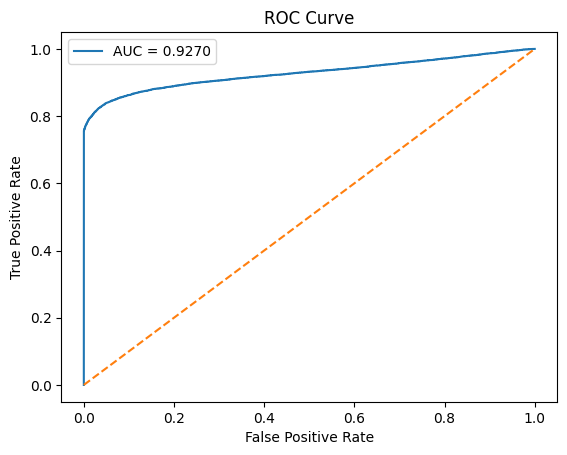

In [44]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()